3.2.2: Birth Rate Analysis

In the 1990s, data were collected from 155 women who were 40 years old at the time of a social survey.

Historically, these women belong to the generation of women in their 20s during the 1970s, a period with relatively low fertility rates.

The goal is to compare the number of children between:

- Women without a university degree
- Women with a university degree

## Data

- No university degree: n = 111, total children = 217
- University degree: n = 44, total children = 66

## Prior

{θ_1,θ_2} ~ Gamma(2,1)

## Posterior

θ_1 | data ~ Gamma(219,112)
θ_2 | data ~ Gamma(68,45)

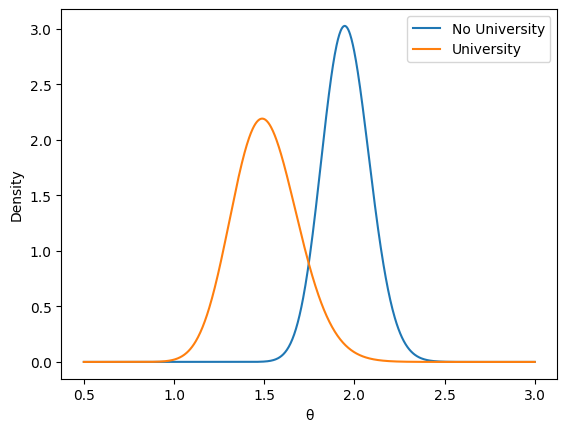

In [1]:
from scipy.stats import gamma
import numpy as np
import matplotlib.pyplot as plt

alpha1, beta1 = 219, 112
alpha2, beta2 = 68, 45

x = np.linspace(0.5, 3.0, 1000)

plt.plot(
    x,
    gamma.pdf(x, a=alpha1, scale=1/beta1),
    label="No University"
)

plt.plot(
    x,
    gamma.pdf(x, a=alpha2, scale=1/beta2),
    label="University"
)

plt.legend()
plt.xlabel("θ")
plt.ylabel("Density")
plt.show()

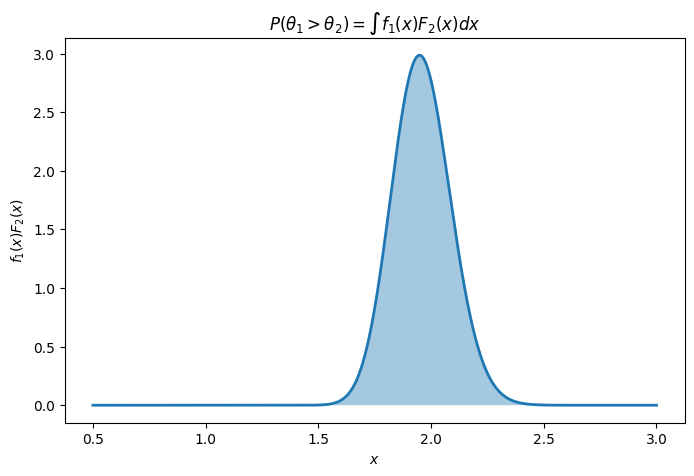

In [2]:
alpha1, beta1 = 219, 112
alpha2, beta2 = 68, 45

x = np.linspace(0.5, 3.0, 1000)

f1 = gamma.pdf(x, a=alpha1, scale=1/beta1)
F2 = gamma.cdf(x, a=alpha2, scale=1/beta2)

integrand = f1 * F2

plt.figure(figsize=(8,5))

plt.plot(x, integrand, lw=2)

plt.fill_between(
    x,
    integrand,
    alpha=0.4
)

plt.title(r"$P(\theta_1 > \theta_2)=\int f_1(x)F_2(x)dx$")
plt.xlabel(r"$x$")
plt.ylabel(r"$f_1(x)F_2(x)$")

plt.show()

In [3]:
from scipy.integrate import quad

alpha1, beta1 = 219,112
alpha2, beta2 = 68,45

f1 = lambda x: gamma.pdf(x, alpha1, scale=1/beta1)
F2 = lambda x: gamma.cdf(x, alpha2, scale=1/beta2)

prob, err = quad(lambda x: f1(x)*F2(x), 0, np.inf)

print(prob)

0.9725600554004145
